# 08 — Modelo Final: Arquitectura Seleccionada

## Configuración ganadora del grid search (07_experimentos.ipynb)

| Componente | Valor |
|---|---|
| Arquitectura | `[256, 128, 64]` — pirámide estándar |
| Dropout | `(0.3, 0.2)` — primera capa / resto |
| Optimizer | Adam · lr=1e-3 |
| Loss Regresión | MAE |
| Loss Clasificación | Focal Loss · γ=2.0 · α=0.75 |
| Threshold clasificación | Óptimo por F1 en validación |
| Split | Cronológico 80 / 10 / 10 |

**Baseline v2:** MAE=2.78d · R²=0.27 · AUC=0.66 · F1=0.095


In [1]:
import os
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    f1_score, roc_auc_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Configuración de GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU disponible: {len(gpus)} dispositivo(s) — memory growth activado')
else:
    print('CPU mode')

print('TensorFlow:', tf.__version__)

DATA_DIR     = Path('../dataset')
MODELS_DIR   = Path('../models')
OUTPUTS_DIR  = Path('../outputs')
GRAFICAS_DIR = Path('../outputs/graficas')
for d in [OUTPUTS_DIR, GRAFICAS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Semilla de reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)


CPU mode
TensorFlow: 2.21.0


## 1. Carga de datos y Feature Engineering

In [2]:
orders    = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp', 'order_delivered_customer_date',
    'order_estimated_delivery_date'])
items     = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv', parse_dates=['shipping_limit_date'])
products  = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
customers = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
sellers   = pd.read_csv(DATA_DIR / 'olist_sellers_dataset.csv')
geo       = pd.read_csv(DATA_DIR / 'olist_geolocation_dataset.csv')
cat_names = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')

# -- Targets
df = orders[(orders['order_status'] == 'delivered') &
             orders['order_delivered_customer_date'].notna()].copy()
df['dias_entrega']   = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['es_retraso']     = (df['order_delivered_customer_date'] > df['order_estimated_delivery_date']).astype(int)
df = df[(df['dias_entrega'] >= 0) & (df['dias_entrega'] <= 60)]
df['dias_estimados'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days

# -- Features temporales
df['mes_compra']        = df['order_purchase_timestamp'].dt.month
df['dia_semana_compra'] = df['order_purchase_timestamp'].dt.dayofweek
df['hora_compra']       = df['order_purchase_timestamp'].dt.hour

# -- Join items
items_agg = items.sort_values('price', ascending=False).groupby('order_id').agg(
    precio_total=('price','sum'), flete_total=('freight_value','sum'),
    product_id=('product_id','first'), seller_id=('seller_id','first'),
    n_items=('order_item_id','count'), shipping_limit_date=('shipping_limit_date','first')
).reset_index()
df = df.merge(items_agg, on='order_id', how='left')
df['dias_limite_envio'] = (df['shipping_limit_date'] - df['order_purchase_timestamp']).dt.days.clip(lower=0)

# -- Join productos
products = products.merge(cat_names, on='product_category_name', how='left')
df = df.merge(products[['product_id','product_category_name_english',
    'product_weight_g','product_length_cm','product_height_cm','product_width_cm']],
    on='product_id', how='left')
df.rename(columns={'product_category_name_english': 'categoria_producto'}, inplace=True)
df['volumen_cm3'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']

# -- Join sellers y clientes
df = df.merge(sellers[['seller_id','seller_zip_code_prefix','seller_state']], on='seller_id', how='left')
df = df.merge(customers[['customer_id','customer_zip_code_prefix','customer_state']], on='customer_id', how='left')
df['mismo_estado'] = (df['seller_state'] == df['customer_state']).astype(int)

# -- Haversine
geo_agg = geo.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat','median'), lng=('geolocation_lng','median')).reset_index()
df = df.merge(geo_agg.rename(columns={'geolocation_zip_code_prefix':'seller_zip_code_prefix',
    'lat':'seller_lat','lng':'seller_lng'}), on='seller_zip_code_prefix', how='left')
df = df.merge(geo_agg.rename(columns={'geolocation_zip_code_prefix':'customer_zip_code_prefix',
    'lat':'customer_lat','lng':'customer_lng'}), on='customer_zip_code_prefix', how='left')

def haversine(lat1, lng1, lat2, lng2):
    R = 6371.0
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lng2-lng1)/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distancia_km'] = haversine(df['seller_lat'], df['seller_lng'],
                                df['customer_lat'], df['customer_lng'])

print(f'Dataset: {len(df):,} órdenes entregadas')
print(f'Retrasos: {df["es_retraso"].sum():,}  ({df["es_retraso"].mean()*100:.1f}%)')


Dataset: 96,182 órdenes entregadas
Retrasos: 7,540  (7.8%)


In [3]:
FEATURES_NUM = [
    'distancia_km', 'precio_total', 'flete_total',
    'product_weight_g', 'volumen_cm3',
    'mes_compra', 'dia_semana_compra', 'hora_compra',
    'dias_estimados', 'dias_limite_envio', 'n_items', 'mismo_estado'
]
FEATURES_CAT = ['categoria_producto', 'customer_state', 'seller_state']
TARGETS      = ['dias_entrega', 'es_retraso']

df_modelo = df[FEATURES_NUM + FEATURES_CAT + TARGETS + ['order_purchase_timestamp']].copy()
for col in FEATURES_NUM:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())
for col in FEATURES_CAT:
    df_modelo[col] = df_modelo[col].fillna('desconocido')

# Split cronológico 80 / 10 / 10
df_modelo = df_modelo.sort_values('order_purchase_timestamp').reset_index(drop=True)
n = len(df_modelo)
n_train, n_val = int(n * 0.80), int(n * 0.90)
train = df_modelo.iloc[:n_train].copy()
val   = df_modelo.iloc[n_train:n_val].copy()
test  = df_modelo.iloc[n_val:].copy()

# Escalar y codificar (fit solo en train)
scaler = StandardScaler()
train[FEATURES_NUM] = scaler.fit_transform(train[FEATURES_NUM])
val[FEATURES_NUM]   = scaler.transform(val[FEATURES_NUM])
test[FEATURES_NUM]  = scaler.transform(test[FEATURES_NUM])

encoders, cardinalidades = {}, {}
for col in FEATURES_CAT:
    le = LabelEncoder()
    le.fit(train[col])
    for split in [train, val, test]:
        split[col] = split[col].apply(lambda x: x if x in le.classes_ else 'desconocido')
    train[col] = le.transform(train[col])
    val[col]   = le.transform(val[col])
    test[col]  = le.transform(test[col])
    encoders[col] = le
    cardinalidades[col] = len(le.classes_)

def preparar_inputs(df):
    return [df[FEATURES_NUM].values.astype('float32')] + \
           [df[col].values.astype('int32') for col in FEATURES_CAT]

X_train = preparar_inputs(train)
X_val   = preparar_inputs(val)
X_test  = preparar_inputs(test)

y_train_reg = train['dias_entrega'].values.astype('float32')
y_val_reg   = val['dias_entrega'].values.astype('float32')
y_test_reg  = test['dias_entrega'].values.astype('float32')
y_train_clf = train['es_retraso'].values.astype('float32')
y_val_clf   = val['es_retraso'].values.astype('float32')
y_test_clf  = test['es_retraso'].values.astype('float32')

print(f'Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}')
print(f'Cardinalidades: {cardinalidades}')
print(f'Features numéricas: {len(FEATURES_NUM)} | Categóricas: {len(FEATURES_CAT)}')


Train: 76,945 | Val: 9,618 | Test: 9,619
Cardinalidades: {'categoria_producto': 72, 'customer_state': 27, 'seller_state': 22}
Features numéricas: 12 | Categóricas: 3


## 2. Arquitectura Final y Funciones Auxiliares

La arquitectura seleccionada es la pirámide estándar `[256 → 128 → 64]` con dropout `(0.3, 0.2)`, que obtuvo el mejor balance MAE/generalización en el grid search.

```
Input numérico (12) ─┐
Embedding categoría  ─┤→ Concat → Dense(256)+BN+Drop(0.3)
Embedding estado cliente ─┤       → Dense(128)+BN+Drop(0.2)
Embedding estado vendedor ─┘       → Dense(64)+BN+Drop(0.2)
                                   → Output (linear | sigmoid)
```


In [4]:
# ── Configuración final seleccionada ──────────────────────────────────────
CAPAS_FINAL   = [256, 128, 64]
DROPOUT_FINAL = (0.3, 0.2)
GAMMA_FINAL   = 2.0
ALPHA_FINAL   = 0.75
EPOCHS_MAX    = 120
BATCH_SIZE    = 256

def construir_modelo(cards, n_num, capas, dropout, activacion_salida, nombre_salida):
    inp_num = keras.Input(shape=(n_num,), name='input_numerico')
    emb_inputs, emb_outputs = [], []
    for col, card in cards.items():
        dim = min(50, (card // 2) + 1)
        inp = keras.Input(shape=(1,), name=f'input_{col}', dtype='int32')
        emb = layers.Embedding(input_dim=card, output_dim=dim, name=f'emb_{col}')(inp)
        emb = layers.Flatten()(emb)
        emb_inputs.append(inp)
        emb_outputs.append(emb)

    x = layers.Concatenate()([inp_num] + emb_outputs)
    for i, unidades in enumerate(capas):
        x = layers.Dense(unidades, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout[0] if i == 0 else dropout[1])(x)

    salida = layers.Dense(1, activation=activacion_salida, name=nombre_salida)(x)
    return keras.Model(inputs=[inp_num] + emb_inputs, outputs=salida)


def focal_loss(gamma=2.0, alpha=0.75):
    def loss(y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce     = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * bce)
    return loss


def umbral_optimo(modelo, X_val, y_val):
    probs = modelo.predict(X_val, verbose=0).flatten()
    prec, rec, thr = precision_recall_curve(y_val, probs)
    f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
    return float(thr[np.argmax(f1s)])


def callbacks(monitor, mode='min'):
    return [
        keras.callbacks.EarlyStopping(monitor=monitor, patience=10,
            restore_best_weights=True, mode=mode, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
            patience=5, min_lr=1e-6, verbose=0)
    ]

print(f'Arquitectura final: {CAPAS_FINAL}  dropout={DROPOUT_FINAL}')
print(f'Focal Loss: γ={GAMMA_FINAL}  α={ALPHA_FINAL}')


Arquitectura final: [256, 128, 64]  dropout=(0.3, 0.2)
Focal Loss: γ=2.0  α=0.75


## 3. Entrenamiento — Modelo de Regresión (ETA)

In [5]:
modelo_reg = construir_modelo(
    cardinalidades, len(FEATURES_NUM),
    CAPAS_FINAL, DROPOUT_FINAL,
    activacion_salida='linear', nombre_salida='dias_entrega'
)
modelo_reg.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='mae', metrics=['mae']
)
modelo_reg.summary()

hist_reg = modelo_reg.fit(
    X_train, y_train_reg,
    validation_data=(X_val, y_val_reg),
    epochs=EPOCHS_MAX, batch_size=BATCH_SIZE,
    callbacks=callbacks('val_loss', 'min'),
    verbose=1
)

# Evaluación en test
pred_reg = modelo_reg.predict(X_test, verbose=0).flatten()
mae_final  = mean_absolute_error(y_test_reg, pred_reg)
rmse_final = np.sqrt(mean_squared_error(y_test_reg, pred_reg))
r2_final   = r2_score(y_test_reg, pred_reg)

print(f'\n{"="*45}')
print(f'  Regresión Final → MAE={mae_final:.4f}d | RMSE={rmse_final:.4f}d | R²={r2_final:.4f}')
print(f'{"="*45}')

modelo_reg.save(MODELS_DIR / 'modelo_regresion_final.keras')
print('Guardado: models/modelo_regresion_final.keras')


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_categoria_pr… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_customer_sta… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_seller_state  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_categoria_prod… │ (None, 1, 37)     │      2,664 │ input_categoria_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_customer_state  │ (None, 1, 14)     │        378 │ input_customer_s… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_seller_state    │ (None, 1, 12)     │        264 │ input_seller_sta… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_numerico      │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 37)        │          0 │ emb_categoria_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 14)        │          0 │ emb_customer_sta… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 12)        │          0 │ emb_seller_state… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 75)        │          0 │ input_numerico[0… │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     19,456 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]   

 Total params: 65,771 (256.92 KB)

 Trainable params: 64,875 (253.42 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/120
301/301 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 9.1170 - mae: 9.1170 - val_loss: 3.3733 - val_mae: 3.3733 - learning_rate: 0.0010
Epoch 2/120
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5.1707 - mae: 5.1707 - val_loss: 3.5727 - val_mae: 3.5727 - learning_rate: 0.0010
Epoch 3/120
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.0329 - mae: 5.0329 - val_loss: 3.5682 - val_mae: 3.5682 - learning_rate: 0.0010
Epoch 4/120
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.9728 - mae: 4.9728 - val_loss: 3.5117 - val_mae: 3.5117 - learning_rate: 0.0010
Epoch 5/120
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.9327 - mae: 4.9327 - val_loss: 3.5072 - val_mae: 3.5072 - learning_rate: 0.0010
Epoch 6/120
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.8900 - mae: 4.8900 - val_loss: 3.5624 - val_mae: 3.5624 - learning_rate: 0.0010
Epoch 7/120
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.8431 - mae: 4.8431 - val_loss: 3.5019 - val_mae: 3.5019 - learning_rate: 5.0000

## 4. Entrenamiento — Modelo de Clasificación (Detección de Retrasos)

In [6]:
modelo_clf = construir_modelo(
    cardinalidades, len(FEATURES_NUM),
    CAPAS_FINAL, DROPOUT_FINAL,
    activacion_salida='sigmoid', nombre_salida='es_retraso'
)
modelo_clf.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=focal_loss(gamma=GAMMA_FINAL, alpha=ALPHA_FINAL),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

hist_clf = modelo_clf.fit(
    X_train, y_train_clf,
    validation_data=(X_val, y_val_clf),
    epochs=EPOCHS_MAX, batch_size=BATCH_SIZE,
    callbacks=callbacks('val_auc', 'max'),
    verbose=1
)

# Umbral óptimo en validación + evaluación en test
umbral = umbral_optimo(modelo_clf, X_val, y_val_clf)
probs_clf = modelo_clf.predict(X_test, verbose=0).flatten()
preds_clf = (probs_clf >= umbral).astype(int)

auc_final = roc_auc_score(y_test_clf, probs_clf)
f1_final  = f1_score(y_test_clf, preds_clf)

print(f'\n{"="*55}')
print(f'  Clasificación Final → AUC={auc_final:.4f} | F1={f1_final:.4f} | umbral={umbral:.4f}')
print(f'{"="*55}')
print(f'\n{classification_report(y_test_clf, preds_clf, target_names=["A tiempo","Retraso"])}')

modelo_clf.save(MODELS_DIR / 'modelo_clasificacion_final.keras')
print('Guardado: models/modelo_clasificacion_final.keras')


Epoch 1/120
301/301 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7758 - auc: 0.5897 - loss: 0.0545 - val_accuracy: 0.9789 - val_auc: 0.7439 - val_loss: 0.0183 - learning_rate: 0.0010
Epoch 2/120
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8699 - auc: 0.6758 - loss: 0.0393 - val_accuracy: 0.9739 - val_auc: 0.7769 - val_loss: 0.0167 - learning_rate: 0.0010
Epoch 3/120
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8852 - auc: 0.7081 - loss: 0.0367 - val_accuracy: 0.9745 - val_auc: 0.7803 - val_loss: 0.0161 - learning_rate: 0.0010
Epoch 4/120
301/301 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8891 - auc: 0.7290 - loss: 0.0355 - val_accuracy: 0.9766 - val_auc: 0.7840 - val_loss: 0.0155 - learning_rate: 0.0010
Epoch 5/120
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8925 - auc: 0.7400 - loss: 0.0349 - val_accuracy: 0.9779 - val_auc: 0.7942 - val_loss: 0.0152 - learning_rate: 0.0010
Epoch 6/120
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8938 - a

## 5. Resultados y Visualizaciones

### 5.1 Curvas de aprendizaje

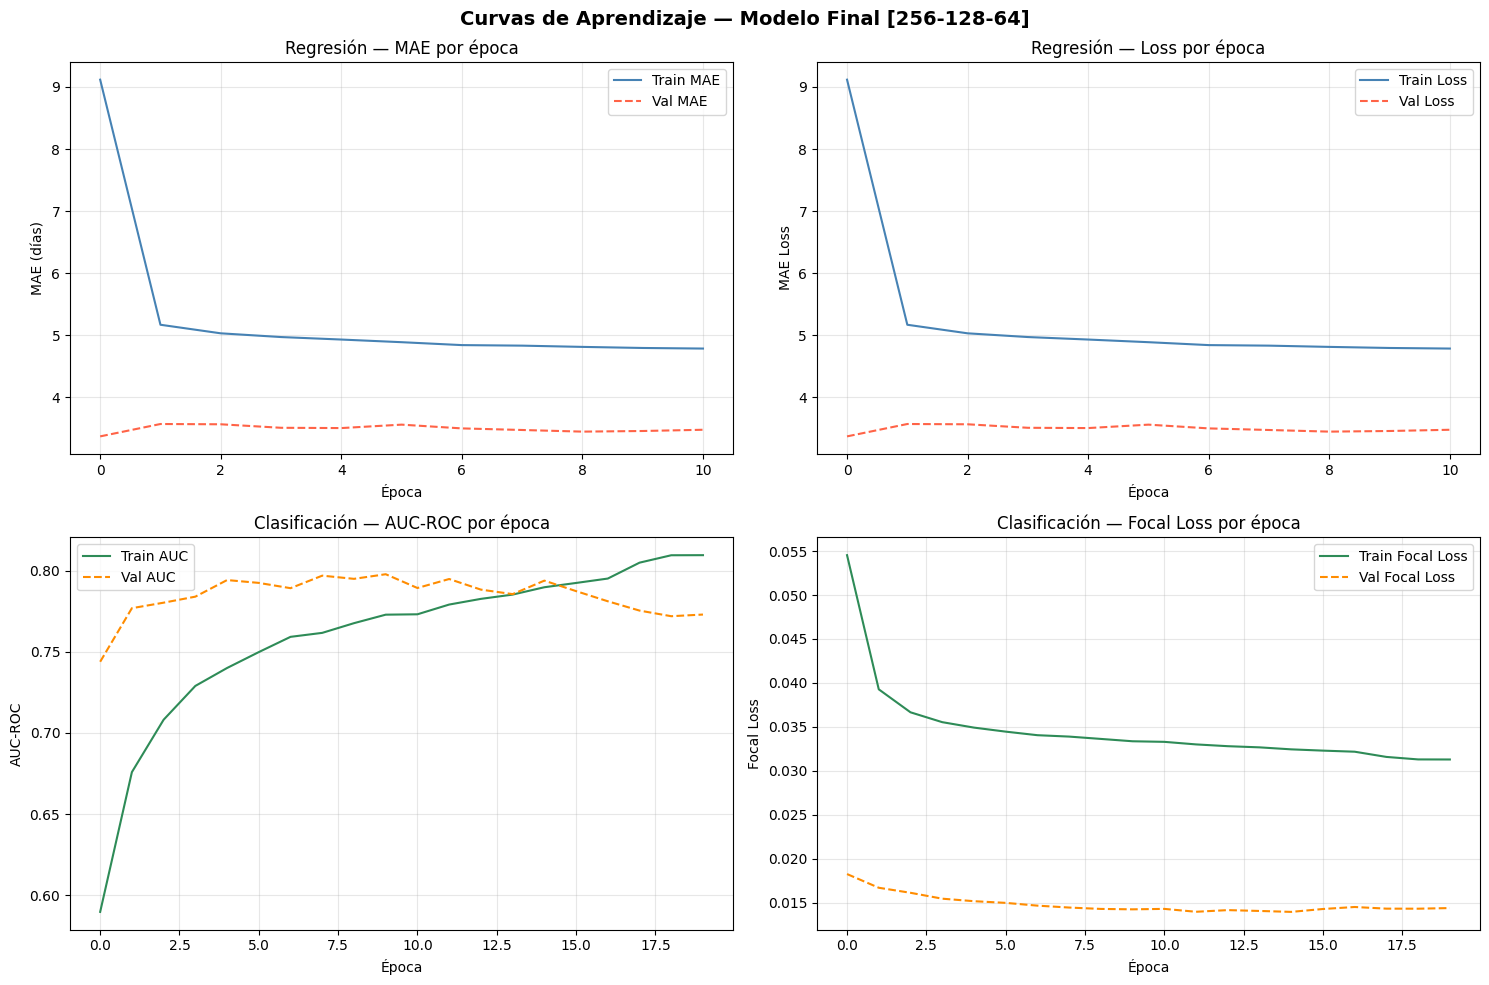

Guardado: outputs/graficas/final_curvas_aprendizaje.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Curvas de Aprendizaje — Modelo Final [256-128-64]', fontsize=14, fontweight='bold')

# Regresión — MAE
ax = axes[0, 0]
ax.plot(hist_reg.history['mae'],     label='Train MAE', color='steelblue')
ax.plot(hist_reg.history['val_mae'], label='Val MAE',   color='tomato', linestyle='--')
ax.set_title('Regresión — MAE por época')
ax.set_xlabel('Época'); ax.set_ylabel('MAE (días)')
ax.legend(); ax.grid(alpha=0.3)

# Regresión — Loss
ax = axes[0, 1]
ax.plot(hist_reg.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(hist_reg.history['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
ax.set_title('Regresión — Loss por época')
ax.set_xlabel('Época'); ax.set_ylabel('MAE Loss')
ax.legend(); ax.grid(alpha=0.3)

# Clasificación — AUC
ax = axes[1, 0]
ax.plot(hist_clf.history['auc'],     label='Train AUC', color='seagreen')
ax.plot(hist_clf.history['val_auc'], label='Val AUC',   color='darkorange', linestyle='--')
ax.set_title('Clasificación — AUC-ROC por época')
ax.set_xlabel('Época'); ax.set_ylabel('AUC-ROC')
ax.legend(); ax.grid(alpha=0.3)

# Clasificación — Loss
ax = axes[1, 1]
ax.plot(hist_clf.history['loss'],     label='Train Focal Loss', color='seagreen')
ax.plot(hist_clf.history['val_loss'], label='Val Focal Loss',   color='darkorange', linestyle='--')
ax.set_title('Clasificación — Focal Loss por época')
ax.set_xlabel('Época'); ax.set_ylabel('Focal Loss')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(GRAFICAS_DIR / 'final_curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: outputs/graficas/final_curvas_aprendizaje.png')


### 5.2 Análisis de Regresión: residuos y predicciones

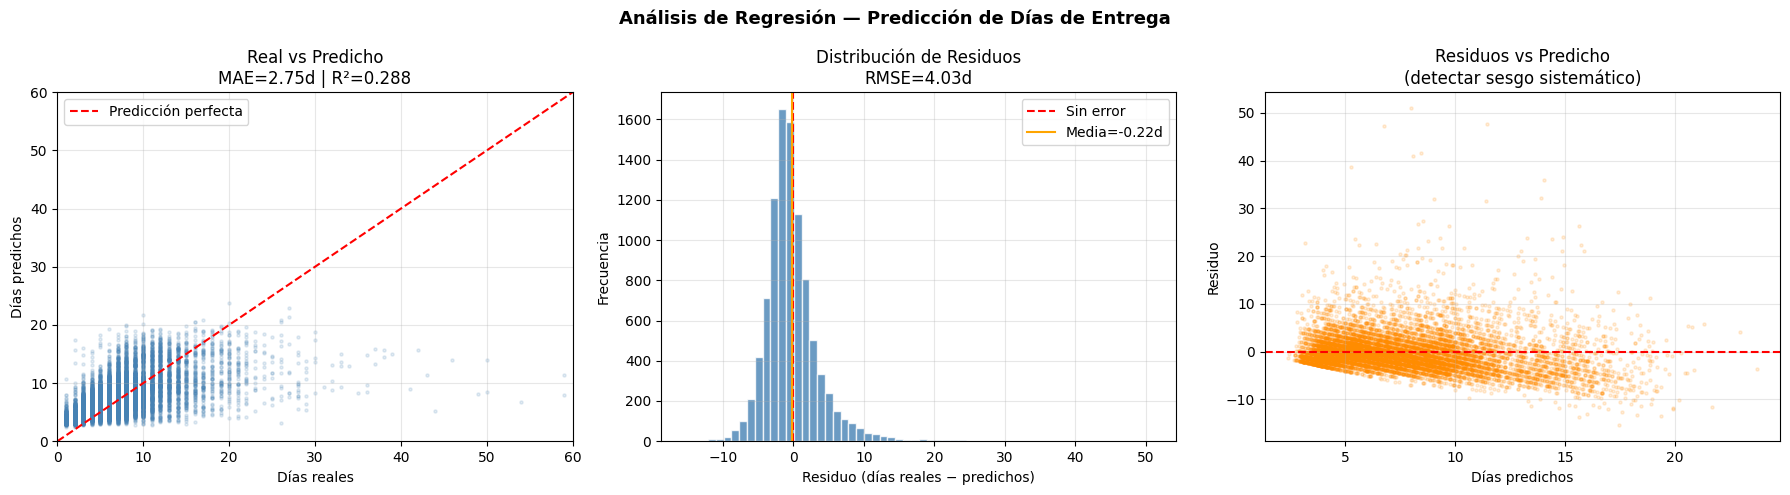

Guardado: outputs/graficas/final_regresion_analisis.png


In [8]:
residuos = y_test_reg - pred_reg

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis de Regresión — Predicción de Días de Entrega', fontsize=13, fontweight='bold')

# Panel 1: Real vs Predicho
ax = axes[0]
lim = [0, 60]
ax.scatter(y_test_reg, pred_reg, alpha=0.15, s=5, color='steelblue', rasterized=True)
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Días reales'); ax.set_ylabel('Días predichos')
ax.set_title(f'Real vs Predicho\nMAE={mae_final:.2f}d | R²={r2_final:.3f}')
ax.legend(); ax.grid(alpha=0.3)

# Panel 2: Distribución de residuos
ax = axes[1]
ax.hist(residuos, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0,                  color='red',    linestyle='--', linewidth=1.5, label='Sin error')
ax.axvline(residuos.mean(),    color='orange', linestyle='-',  linewidth=1.5, label=f'Media={residuos.mean():.2f}d')
ax.set_xlabel('Residuo (días reales − predichos)')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución de Residuos\nRMSE={rmse_final:.2f}d')
ax.legend(); ax.grid(alpha=0.3)

# Panel 3: Residuos vs Predicho (homocedasticidad)
ax = axes[2]
ax.scatter(pred_reg, residuos, alpha=0.15, s=5, color='darkorange', rasterized=True)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Días predichos'); ax.set_ylabel('Residuo')
ax.set_title('Residuos vs Predicho\n(detectar sesgo sistemático)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(GRAFICAS_DIR / 'final_regresion_analisis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: outputs/graficas/final_regresion_analisis.png')


### 5.3 Análisis de Clasificación: ROC, Precision-Recall y Matriz de Confusión

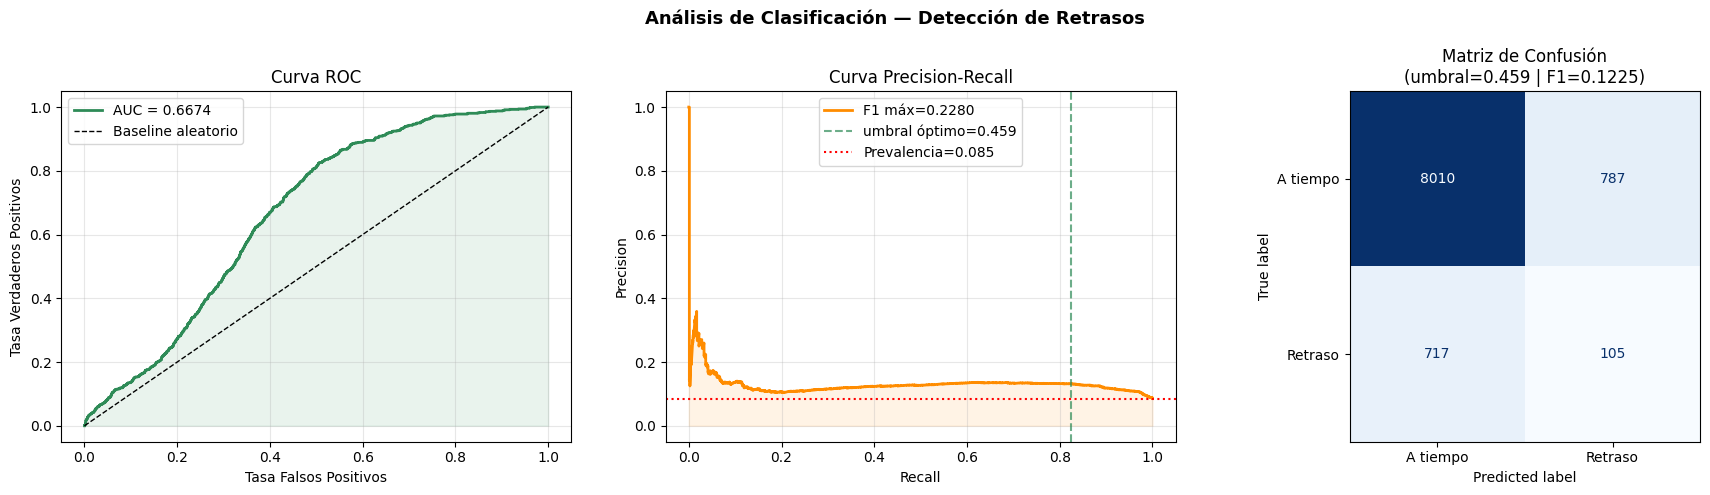

Guardado: outputs/graficas/final_clasificacion_analisis.png


In [9]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis de Clasificación — Detección de Retrasos', fontsize=13, fontweight='bold')

# Panel 1: Curva ROC
ax = axes[0]
fpr, tpr, _ = roc_curve(y_test_clf, probs_clf)
ax.plot(fpr, tpr, color='seagreen', linewidth=2, label=f'AUC = {auc_final:.4f}')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Baseline aleatorio')
ax.fill_between(fpr, tpr, alpha=0.1, color='seagreen')
ax.set_xlabel('Tasa Falsos Positivos'); ax.set_ylabel('Tasa Verdaderos Positivos')
ax.set_title('Curva ROC')
ax.legend(); ax.grid(alpha=0.3)

# Panel 2: Curva Precision-Recall
ax = axes[1]
prec_curve, rec_curve, thr_curve = precision_recall_curve(y_test_clf, probs_clf)
f1_curve = 2 * prec_curve[:-1] * rec_curve[:-1] / (prec_curve[:-1] + rec_curve[:-1] + 1e-8)
idx_best = np.argmax(f1_curve)
ax.plot(rec_curve, prec_curve, color='darkorange', linewidth=2, label=f'F1 máx={f1_curve[idx_best]:.4f}')
ax.axvline(rec_curve[idx_best], color='seagreen', linestyle='--', alpha=0.7,
           label=f'umbral óptimo={umbral:.3f}')
ax.fill_between(rec_curve, prec_curve, alpha=0.1, color='darkorange')
prevalencia = y_test_clf.mean()
ax.axhline(prevalencia, color='red', linestyle=':', linewidth=1.5, label=f'Prevalencia={prevalencia:.3f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall')
ax.legend(); ax.grid(alpha=0.3)

# Panel 3: Matriz de Confusión
ax = axes[2]
cm = confusion_matrix(y_test_clf, preds_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A tiempo', 'Retraso'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title(f'Matriz de Confusión\n(umbral={umbral:.3f} | F1={f1_final:.4f})')

plt.tight_layout()
plt.savefig(GRAFICAS_DIR / 'final_clasificacion_analisis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: outputs/graficas/final_clasificacion_analisis.png')


### 5.4 Tabla Comparativa v1 → v2 → Final

In [10]:
with open(OUTPUTS_DIR / 'metricas.json', 'r') as f:
    m1 = json.load(f)
with open(OUTPUTS_DIR / 'metricas_v2.json', 'r') as f:
    m2 = json.load(f)

metricas = {
    'MAE (días)':  [m1['regresion']['mae_dias'],   m2['regresion']['mae_dias'],   round(mae_final, 4)],
    'RMSE (días)': [m1['regresion']['rmse_dias'],  m2['regresion']['rmse_dias'],  round(rmse_final, 4)],
    'R²':          [m1['regresion']['r2'],          m2['regresion']['r2'],         round(r2_final, 4)],
    'AUC-ROC':     [m1['clasificacion']['auc_roc'], m2['clasificacion']['auc_roc'],round(auc_final, 4)],
    'F1-score':    [m1['clasificacion']['f1_score'],m2['clasificacion']['f1_score'],round(f1_final, 4)],
}
tabla = pd.DataFrame(metricas, index=['v1 (baseline)', 'v2 (features)', 'Final [256-128-64]']).T

# Calcular mejora porcentual final vs v1
tabla['Δ final vs v1'] = tabla.apply(
    lambda row: f"{((row['Final [256-128-64]'] - row['v1 (baseline)']) / abs(row['v1 (baseline)'])) * 100:+.1f}%", axis=1)

pd.set_option('display.float_format', '{:.4f}'.format)
print('='*65)
print(' RESULTADOS COMPARATIVOS — MODELO FINAL')
print('='*65)
print(tabla.to_string())
print('='*65)


 RESULTADOS COMPARATIVOS — MODELO FINAL
             v1 (baseline)  v2 (features)  Final [256-128-64] Δ final vs v1
MAE (días)          3.2555         2.7769              2.7479        -15.6%
RMSE (días)         4.3901         4.0796              4.0278         -8.3%
R²                  0.1546         0.2700              0.2884        +86.5%
AUC-ROC             0.5565         0.6624              0.6674        +19.9%
F1-score            0.0326         0.0952              0.1225       +275.8%


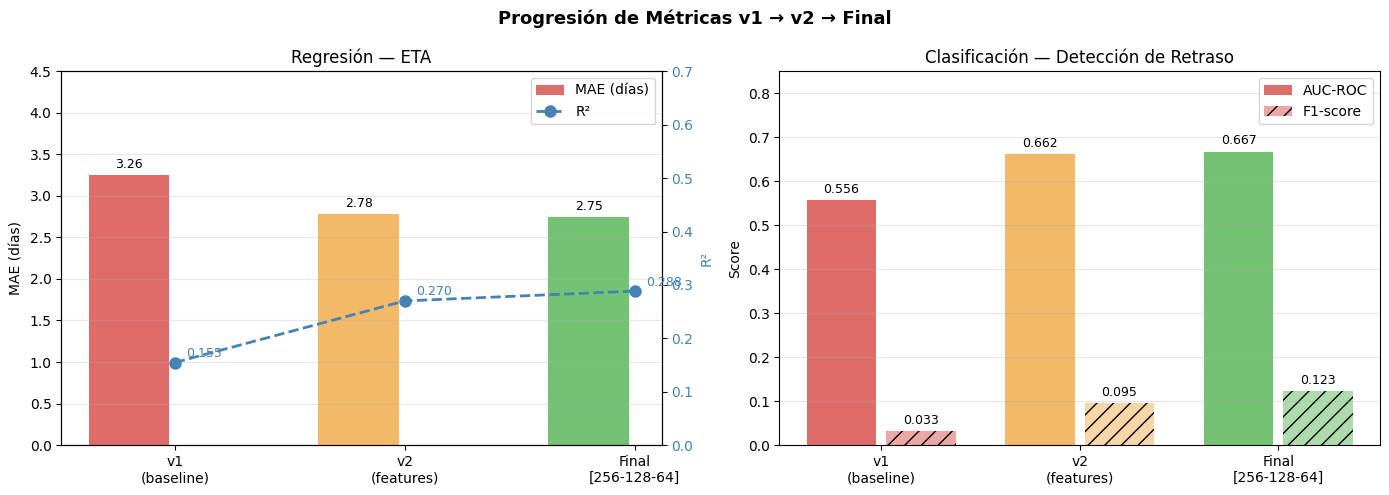

Guardado: outputs/graficas/final_comparativa_versiones.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Progresión de Métricas v1 → v2 → Final', fontsize=13, fontweight='bold')

versiones = ['v1\n(baseline)', 'v2\n(features)', 'Final\n[256-128-64]']
colores   = ['#d9534f', '#f0ad4e', '#5cb85c']

# Panel 1: Métricas de regresión
ax = axes[0]
mae_vals  = [m1['regresion']['mae_dias'],  m2['regresion']['mae_dias'],  mae_final]
r2_vals   = [m1['regresion']['r2'],        m2['regresion']['r2'],        r2_final]

x = np.arange(len(versiones))
bars = ax.bar(x - 0.2, mae_vals, width=0.35, color=colores, alpha=0.85, label='MAE (días)')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

ax2 = ax.twinx()
ax2.plot(x, r2_vals, 'o--', color='steelblue', linewidth=2, markersize=8, label='R²')
for i, v in enumerate(r2_vals):
    ax2.annotate(f'{v:.3f}', (i, v), textcoords='offset points', xytext=(8, 4),
                 color='steelblue', fontsize=9)
ax2.set_ylabel('R²', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.set_ylim(0, 0.7)

ax.set_xticks(x); ax.set_xticklabels(versiones)
ax.set_ylabel('MAE (días)'); ax.set_title('Regresión — ETA')
ax.set_ylim(0, 4.5)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Panel 2: Métricas de clasificación
ax = axes[1]
auc_vals = [m1['clasificacion']['auc_roc'], m2['clasificacion']['auc_roc'], auc_final]
f1_vals  = [m1['clasificacion']['f1_score'],m2['clasificacion']['f1_score'],f1_final]

bars1 = ax.bar(x - 0.2, auc_vals, width=0.35, color=colores, alpha=0.85, label='AUC-ROC')
bars2 = ax.bar(x + 0.2, f1_vals,  width=0.35, color=colores, alpha=0.5,  label='F1-score', hatch='//')
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(versiones)
ax.set_ylabel('Score'); ax.set_title('Clasificación — Detección de Retraso')
ax.set_ylim(0, 0.85)
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(GRAFICAS_DIR / 'final_comparativa_versiones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: outputs/graficas/final_comparativa_versiones.png')


## 6. Guardar Métricas Finales

In [12]:
metricas_final = {
    "modelo": "final_[256-128-64]_drop(0.3,0.2)",
    "arquitectura": {
        "capas":   CAPAS_FINAL,
        "dropout": list(DROPOUT_FINAL),
    },
    "regresion": {
        "mae_dias":  round(mae_final,  4),
        "rmse_dias": round(rmse_final, 4),
        "r2":        round(r2_final,   4),
        "loss":      "mae",
    },
    "clasificacion": {
        "auc_roc":           round(auc_final, 4),
        "f1_score":          round(f1_final,  4),
        "umbral_optimo":     round(umbral,    4),
        "focal_loss_gamma":  GAMMA_FINAL,
        "focal_loss_alpha":  ALPHA_FINAL,
        "n_retrasos_reales":    int(y_test_clf.sum()),
        "n_retrasos_predichos": int(preds_clf.sum()),
        "prevalencia_test":     round(float(y_test_clf.mean()), 4),
    },
    "entrenamiento": {
        "epochs_max":  EPOCHS_MAX,
        "batch_size":  BATCH_SIZE,
        "optimizer":   "Adam lr=1e-3",
        "early_stopping_patience": 10,
    }
}

with open(OUTPUTS_DIR / 'metricas_final.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_final, f, ensure_ascii=False, indent=2)

print('Guardado: outputs/metricas_final.json')
print()
print(json.dumps(metricas_final, indent=2))


Guardado: outputs/metricas_final.json

{
  "modelo": "final_[256-128-64]_drop(0.3,0.2)",
  "arquitectura": {
    "capas": [
      256,
      128,
      64
    ],
    "dropout": [
      0.3,
      0.2
    ]
  },
  "regresion": {
    "mae_dias": 2.7479,
    "rmse_dias": 4.0278,
    "r2": 0.2884,
    "loss": "mae"
  },
  "clasificacion": {
    "auc_roc": 0.6674,
    "f1_score": 0.1225,
    "umbral_optimo": 0.4592,
    "focal_loss_gamma": 2.0,
    "focal_loss_alpha": 0.75,
    "n_retrasos_reales": 822,
    "n_retrasos_predichos": 892,
    "prevalencia_test": 0.0855
  },
  "entrenamiento": {
    "epochs_max": 120,
    "batch_size": 256,
    "optimizer": "Adam lr=1e-3",
    "early_stopping_patience": 10
  }
}
